# Lab 1: Fundamentals of Signal and Audio Processing
You will explore the basics of signals and audio through Python, visualization, real sound files, and audio processing using `librosa`.
---

## Part A – Theoretical Questions (4 pts)
Answer the following exercises before moving to the coding part.
### Ex. 1 – Signal Transformations (2 pts)

We consider a discrete-time, non-periodic signal defined as:
```python
xn = δ[n] − 1.1·δ[n−4]
fe = 2 Hz
```
1. What happens when we amplify the signal by a factor of 2?
2. What happens when we add 2 to the signal?
3. What happens when we dilate the time scale by a factor of 2?
4. What happens when we delay the signal by one second?




**Answer**

1) xn = 2·δ[n] − 2.2·δ[n−4]

2) xn = δ[n] − 1.1·δ[n−4] + 2

3) xn_dilated = δ[n/2] − 1.1·δ[(n−4)/2]

4) fe=2Hz⇒Te =0.5s
So, each index n corresponds to 0.5 seconds, so a delay of 1 second corresponds to 2 samples
xn_delayed = δ[n−2] − 1.1·δ[n−6]


### Ex. 2 – Sampling Signal with Gaps (2 pts)


Signal values: t = [0, 15, 30] → [0.5, 0, 1.5]
1. Interpret this as a discrete-time signal. What is the sampling frequency?
2. Compute the energy
3. Interpret this as a periodic signal and plot it
4. Compute the power

**ANSWERS**

Sampling period Te = 15 s
Sampling frequency fe = 0.06666666666666667 Hz
Signal energy = 2.50


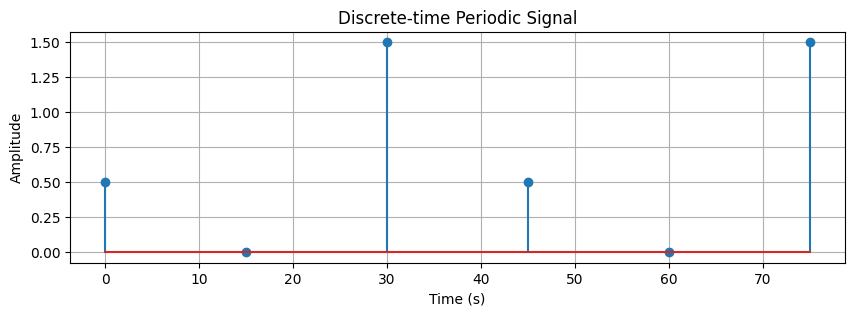

Signal power = 0.83


In [2]:
# ANSWER

import numpy as np
import matplotlib.pyplot as plt

# Data
t = np.array([0, 15, 30])  # in seconds
x = np.array([0.5, 0, 1.5])

# 1. Interpret as a discrete-time signal. What is the sampling frequency?
T_e = t[1] - t[0]
f_e = 1 / T_e
print(f"Sampling period Te = {T_e} s")
print(f"Sampling frequency fe = {f_e} Hz")

# 2. Energy for discrete signal: E = sum(|x[n]|^2)
energy = np.sum(x**2)
print(f"Signal energy = {energy:.2f}")

# 3. We repeat the pattern every 3 samples (i.e., 45 seconds)
t_periodic = np.arange(0, 90, 15)
x_periodic = np.tile(x, 2)  # repeat pattern
x_periodic = np.append(x_periodic, x[:len(t_periodic)-len(x_periodic)])  # match length

plt.figure(figsize=(10, 3))
plt.stem(t_periodic, x_periodic)
plt.title("Discrete-time Periodic Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# 4. Power = (1/N) * sum_{n=0}^{N-1} |x[n]|^2
N = len(x)
power = np.sum(x**2) / N
print(f"Signal power = {power:.2f}")


#  **Part 2 – Practical Signal Processing in Python** (16 pts)

# 1) – What is a Signal? (1 pt)

In [7]:
examples = {
    "temperature": [21, 22, 23, 24, 25, 24, 23, 22],
    "image": [[255, 128], [0, 64]],
    "stock_prices": [100, 102, 105, 98, 95, 100, 104],
    "heartbeat": [0.8, 1.0, 0.9, 1.1, 1.2],
    "ice_cream_sales": [200, 220, 250, 180, 210, 230]
}

for name, data in examples.items():
    print(f"{name}: {data}")

temperature: [21, 22, 23, 24, 25, 24, 23, 22]
image: [[255, 128], [0, 64]]
stock_prices: [100, 102, 105, 98, 95, 100, 104]
heartbeat: [0.8, 1.0, 0.9, 1.1, 1.2]
ice_cream_sales: [200, 220, 250, 180, 210, 230]


**Questions**

*   Which of these are signals? Justify.
*   Which are continuous-time? Discrete-time?




**ANSWERS**

## 2) – Playing Sinusoidal Signals (2 pt)

* Generate a sine wave for middle A (440 Hz) and A5 (880 Hz) and plot them

* Play both and compare.

**ANSWER**

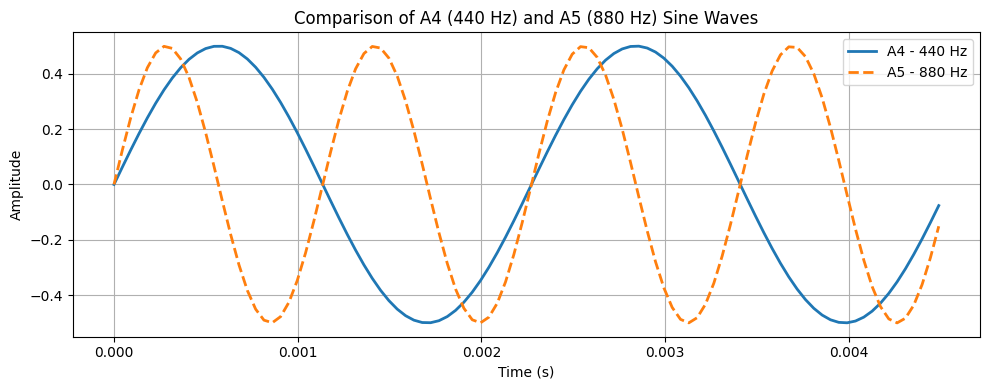

A4:


In [7]:
from IPython.display import Audio
import numpy as np
sr = 22050
t = np.linspace(0, 1, sr)

a4 = 0.5 * np.sin(2 * np.pi * 440 * t)
a5 = 0.5 * np.sin(2 * np.pi * 880 * t)

time_window = t[:100]
a4_window = a4[:100]
a5_window = a5[:100]

# Plot
plt.figure(figsize=(10, 4))
plt.plot(time_window, a4_window, label='A4 - 440 Hz', linewidth=2)
plt.plot(time_window, a5_window, label='A5 - 880 Hz', linestyle='--', linewidth=2)
plt.title("Comparison of A4 (440 Hz) and A5 (880 Hz) Sine Waves")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("A4:")
Audio(a4, rate=sr)


In [6]:
print("A5:")
Audio(a5, rate=sr)

A5:


## 3) – Sampling and Aliasing (6 pts)

1. **Generate the original signal**:
   - A 440 Hz sine wave over 2 seconds
   - Sample it with a very high sampling rate (1000 Hz or more) to simulate a continuous signal

2. **Sample the signal at different rates**:
   - Fs = 5000 Hz
   - Fs = 1000 Hz
   - Fs = 500 Hz
   - Fs = 100 Hz

   For each sampling frequency:
   - Downsample the original signal
   - Plot the downsampled signal over the original
   - Use stem plots to clearly show sample points
   - Play back the downsampled version using `IPython.display.Audio`

**QUESTIONS**

   - What is the Nyquist Theorem? Explain it and state it mathematically.
   - What is the minimum sampling rate to avoid aliasing for a 440 Hz signal?
   - Is there a sampling frequency where the tone becomes unrecognizable?



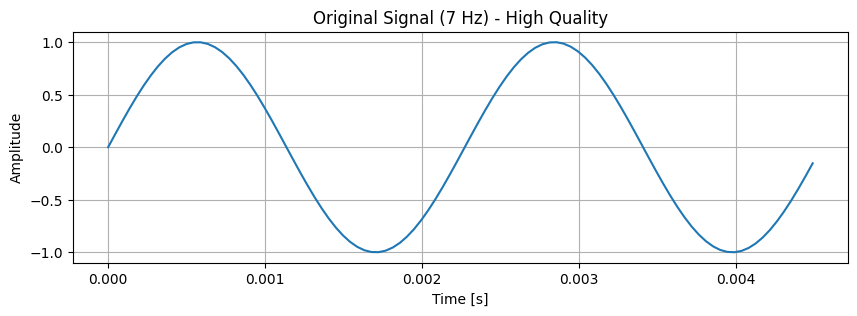

🎧 Listen to the Original 7 Hz Signal at 22050 Hz Sampling Rate:


In [30]:
# ORIGINAL signal

sr = 22050  # high sampling rate
duration = 3.0  # seconds
f = 440  # Hz
t = np.linspace(0, duration, int(sr * duration), endpoint=False)
x_orig = np.sin(2 * np.pi * f * t)

# Plot original
plt.figure(figsize=(10, 3))
plt.plot(t[0:100], x_orig[0:100])
plt.title("Original Signal (7 Hz) - High Quality")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print("🎧 Listen to the Original 7 Hz Signal at 22050 Hz Sampling Rate:")
display(Audio(x_orig, rate=sr))  # High fidelity playback

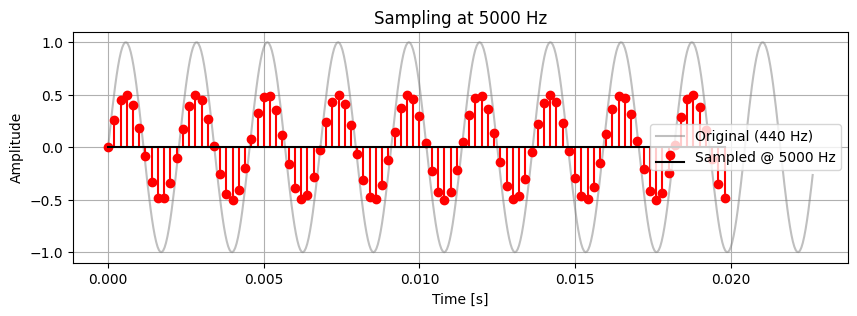

🔊 Listen to sampled signal at 5000 Hz:


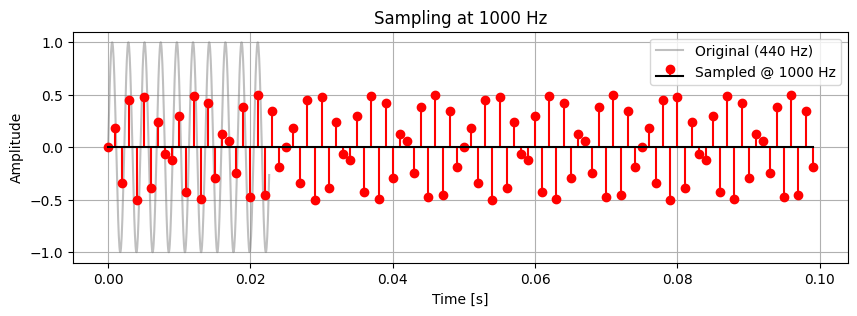

🔊 Listen to sampled signal at 1000 Hz:


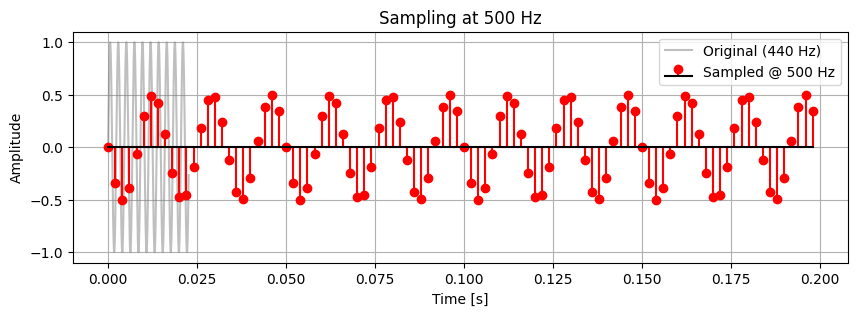

🔊 Listen to sampled signal at 500 Hz:


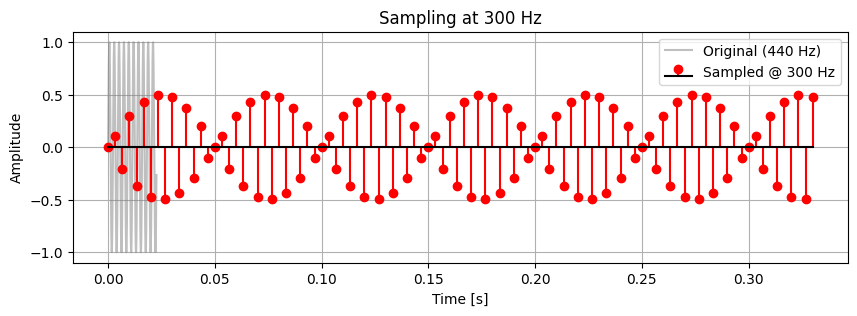

🔊 Listen to sampled signal at 300 Hz:


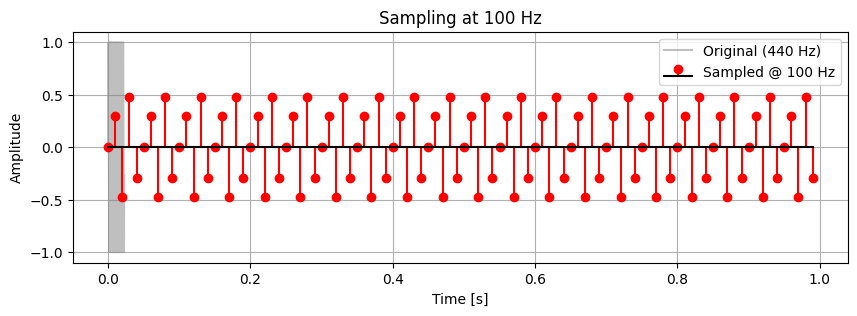

🔊 Listen to sampled signal at 100 Hz:


In [41]:
# Sampling versions
t_cont = np.linspace(0, duration, 1000)
x_cont = np.sin(2 * np.pi * f * t_cont)

sample_rates = [5000,1000, 500, 300, 100]
audios = {}

for Fs in sample_rates:
    Ts = 1 / Fs
    t_samp = np.arange(0, duration, Ts)
    x_samp = 0.5 * np.sin(2 * np.pi * f * t_samp)

    # Interpolate to 22050 Hz for playback
    t_interp = np.linspace(0, duration, int(sr * duration), endpoint=False)
    x_interp = np.interp(t_interp, t_samp, x_samp)

    # Plot
    plt.figure(figsize=(10, 3))
    plt.plot(t[0:500], x_orig[0:500], 'gray', alpha=0.5, label='Original (440 Hz)')
    plt.stem(t_samp[0:100], x_samp[0:100], linefmt='r-', markerfmt='ro', basefmt='k-', label=f'Sampled @ {Fs} Hz')
    plt.title(f"Sampling at {Fs} Hz")
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.legend()
    plt.show()

    # Play audio
    print(f"🔊 Listen to sampled signal at {Fs} Hz:")
    display(Audio(x_interp, rate=sr))

**Answers**

   - What is the Nyquist Theorem? Explain it and state it mathematically.

The Nyquist Theorem (or Nyquist-Shannon Sampling Theorem) states that in order to sample a continuous signal without losing information, the sampling frequency must be at least twice the highest frequency component of the signal.

   - What is the minimum sampling rate to avoid aliasing for a 440 Hz signal?

   Any sampling rate below 880 Hz risks introducing aliasing in a 440 Hz sine wave.

   - Is there a sampling frequency where the tone becomes unrecognizable?

   < 200Hz

## 4) – Librosa: Basics of Audio I/O and Visualization (1 pt)

In [51]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd

# Load file with specific sample rate
file = librosa.ex('trumpet')
x, sr = librosa.load(file, sr=22050)
x1, sr1 = librosa.load(file, sr=1000)

print(f'Sample rate: {sr}, Duration: {len(x)/sr:.2f} seconds')

# Play audio
ipd.Audio(x, rate=sr)

Sample rate: 22050, Duration: 5.33 seconds


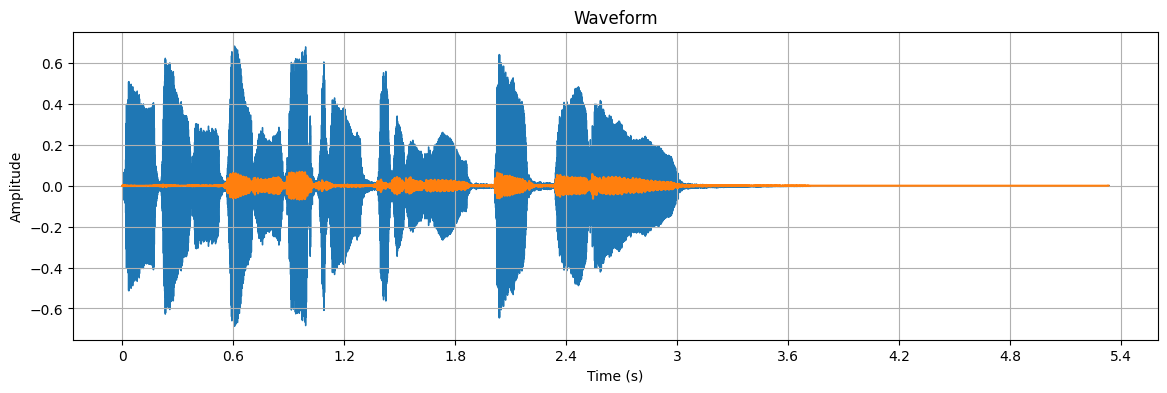

In [52]:
# Waveform visualization
plt.figure(figsize=(14, 4))
librosa.display.waveshow(x, sr=sr)
librosa.display.waveshow(x1, sr=sr1)

plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

**Questions**

- What does the waveform represent visually?

- What would happen if we used a sampling rate of 8000 Hz instead?

**Answers**

- The waveform plot represents how the amplitude (i.e., the strength or loudness) of the audio signal changes over time.

- Using a sampling rate of 8000 Hz would mean that the audio is recorded or resampled at 8000 samples per second instead of 22050: Lower audio quality & Smaller file size

## 5) – Hearing Frequency Limit – How High Can You Hear? (3 pts)

- Write your own function to generate a sine wave (beep(frequency)).

- Use IPython.display.Audio() to play the sound.

- Try frequencies: 5000, 10000, 15000, 18000, 20000, 25000 Hz.



> Ajouter une citation



In [55]:
def beep(frequency):
    t = np.linspace(0, 1, 44100)
    wave = 0.5 * np.sin(2 * np.pi * frequency * t)
    return wave

# TODO: Replace these with the frequencies you want to test
for freq in [5000, 10000, 15000, 18000, 20000, 25000]:
    print(f"🔊 Playing {freq} Hz")
    display(Audio(beep(freq), rate=44100))

🔊 Playing 5000 Hz


🔊 Playing 10000 Hz


🔊 Playing 15000 Hz


🔊 Playing 18000 Hz


🔊 Playing 20000 Hz


🔊 Playing 25000 Hz


## 6) – Compose your music (3 pts)

- Write a function to generate a tone for a given note name and duration.

- Create a list of notes and durations (a short melody).

- Combine the tones to form your custom song.

- Use IPython.display.Audio() to listen to your melody.


note_freqs = {
    "C4": 261.63, "D4": 293.66, "E4": 329.63, "F4": 349.23,
    "G4": 392.00, "A4": 440.00, "Bb4": 466.16, "B4": 493.88,
    "C5": 523.25, "D5": 587.33, "E5": 659.25, "F5": 698.46,
    "G5": 783.99, "A5": 880.00, "R": 0.0  # Rest
}

In [59]:
sr = 22050

def generate_tone(freq, duration, sr=22050):
    t = np.linspace(0, duration, int(sr * duration), False)
    if freq == 0:
        return np.zeros_like(t)  # rest
    tone = 0.5 * np.sin(2 * np.pi * freq * t)
    return tone

note_freqs = {
    "C4": 261.63, "D4": 293.66, "E4": 329.63, "F4": 349.23,
    "G4": 392.00, "A4": 440.00, "Bb4": 466.16, "B4": 493.88,
    "C5": 523.25, "D5": 587.33, "E5": 659.25, "F5": 698.46,
    "G5": 783.99, "A5": 880.00, "R": 0.0  # Rest
}
melody = [("C4", 0.4), ("D4", 0.4), ("E4", 0.4), ("C4", 0.4),
          ("C4", 0.4), ("D4", 0.4), ("E4", 0.4), ("C4", 0.4),
          ("E4", 0.4), ("F4", 0.4), ("G4", 0.8)]

song = np.concatenate([generate_tone(note_freqs[n], dur, sr) for n, dur in melody])
Audio(song, rate=sr)